# neurobemfullstate 数据处理 walkthrough

这个 notebook 只看数据处理，不碰训练代码。

目标是把原始 NeuroBEM CSV 转成 `neurobemfullstate` canonical trajectory dataset。每个时间步保存 31 个特征，不保存 `t` 到 feature 向量里：

```text
[p_W, v_W, q_WB, omega_B, a, alpha, u, v_B, dmot, vbat]
```

其中 `vel x/y/z` 按 NeuroBEM 的说明先作为机体系速度 `v_B` 读取，再用已经验证过的旋转方向转换成世界系速度：

```text
v_W = R(q_WB) @ v_B
```

这样后面训练不同模型时，可以从同一个 HDF5 里按需切列，不用再回头处理 CSV。


## 0. 导入依赖并定位仓库

In [1]:
from pathlib import Path
import json
import shutil
import sys
import tempfile

import h5py
from IPython.display import display
from matplotlib import font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 配置 Matplotlib 中文字体，避免中文标题显示成小方格。
candidate_fonts = ["PingFang SC", "Heiti SC", "STHeiti", "Songti SC", "Arial Unicode MS", "SimHei"]
available_fonts = {font.name for font in fm.fontManager.ttflist}
chinese_font = next((font for font in candidate_fonts if font in available_fonts), None)
if chinese_font:
    plt.rcParams["font.sans-serif"] = [chinese_font, "DejaVu Sans"]
    plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "scripts" / "hdf5.py").exists() and (candidate / "resources").exists():
            return candidate


REPO_ROOT = find_repo_root(Path.cwd())
SCRIPTS_DIR = REPO_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from hdf5 import (
    CANONICAL_DATASET,
    CANONICAL_FEATURE_NAMES,
    CANONICAL_FEATURE_SLICES,
    CANONICAL_DT_SECONDS,
    csv_to_canonical_hdf5,
    extract_neurobem_full_state,
    neurobem_csv_to_canonical_trajectory,
    normalize_and_resample_time,
    write_canonical_split_hdf5,
)

print("项目根目录:", REPO_ROOT)
print("canonical 数据集名:", CANONICAL_DATASET)

项目根目录: /Users/lixiang/Developer/long-horizon-dynamics
canonical 数据集名: neurobemfullstate


## 1. 原始数据和输出目录

`neurobemfullstate` 的输入还是原始 NeuroBEM CSV，输出是新的 canonical HDF5。

In [2]:
SOURCE_DATASET = "neurobem"
SPLIT = "train"

SOURCE_DATA_DIR = REPO_ROOT / "resources" / "data" / SOURCE_DATASET
CANONICAL_DATA_DIR = REPO_ROOT / "resources" / "data" / CANONICAL_DATASET
SPLIT_DIR = SOURCE_DATA_DIR / SPLIT

print("原始 NeuroBEM 目录:", SOURCE_DATA_DIR)
print("canonical 输出目录:", CANONICAL_DATA_DIR)
print("当前查看 split:", SPLIT_DIR)

原始 NeuroBEM 目录: /Users/lixiang/Developer/long-horizon-dynamics/resources/data/neurobem
canonical 输出目录: /Users/lixiang/Developer/long-horizon-dynamics/resources/data/neurobemfullstate
当前查看 split: /Users/lixiang/Developer/long-horizon-dynamics/resources/data/neurobem/train


## 2. 读取一个原始 CSV

In [3]:
csv_files = sorted(SPLIT_DIR.glob("*.csv"))
print("CSV 文件数量:", len(csv_files))
for path in csv_files[:10]:
    print(path.relative_to(REPO_ROOT))

csv_path = csv_files[0]
raw = pd.read_csv(csv_path)

print("当前使用文件:", csv_path.relative_to(REPO_ROOT))
print("原始 shape:", raw.shape)
display(raw.head())
raw.columns

CSV 文件数量: 236
resources/data/neurobem/train/merged_2021-02-03-13-43-38_seg_1.csv
resources/data/neurobem/train/merged_2021-02-03-13-43-38_seg_2.csv
resources/data/neurobem/train/merged_2021-02-03-13-43-38_seg_3.csv
resources/data/neurobem/train/merged_2021-02-03-13-43-38_seg_4.csv
resources/data/neurobem/train/merged_2021-02-03-13-44-49_seg_1.csv
resources/data/neurobem/train/merged_2021-02-03-13-44-49_seg_2.csv
resources/data/neurobem/train/merged_2021-02-03-13-44-49_seg_3.csv
resources/data/neurobem/train/merged_2021-02-03-13-44-49_seg_4.csv
resources/data/neurobem/train/merged_2021-02-03-13-53-04_seg_1.csv
resources/data/neurobem/train/merged_2021-02-03-13-53-04_seg_2.csv
当前使用文件: resources/data/neurobem/train/merged_2021-02-03-13-43-38_seg_1.csv
原始 shape: (1008, 29)


,t,ang acc x,ang acc y,ang acc z,ang vel x,ang vel y,ang vel z,quat x,quat y,quat z,...,pos z,mot 1,mot 2,mot 3,mot 4,dmot 1,dmot 2,dmot 3,dmot 4,vbat
0,0.0025,1.201073,-1.470741,-1.134498,0.492292,-0.241313,0.000316,-0.039668,0.001108,0.067237,...,0.183710,1186.120287,1228.873204,1252.141492,1166.664656,350.488676,-1308.800916,-789.235936,-866.186143,163.936878
1,0.0050,1.885005,-0.990310,-1.024854,0.493187,-0.242492,-0.004493,-0.038974,0.000789,0.067253,...,0.185505,1186.996509,1225.601202,1250.168402,1164.499191,482.942342,-1171.687224,-830.080657,-1017.614188,163.952969
2,0.0075,2.646493,-0.396498,-0.758964,0.495608,-0.244053,-0.008063,-0.038275,0.000485,0.067270,...,0.187299,1188.534999,1223.014768,1247.991089,1161.576585,635.509448,-740.634986,-748.205042,-1128.611115,163.971408
3,0.0100,3.128839,0.160133,-0.479905,0.501754,-0.246108,-0.008637,-0.037572,0.000199,0.067288,...,0.189092,1190.174056,1221.898027,1246.427377,1158.856135,702.757075,-282.399694,-591.840478,-1136.487752,163.986057
4,0.0125,3.295224,0.825937,-0.204945,0.513369,-0.248168,-0.007385,-0.036871,-0.000074,0.067304,...,0.190884,1192.048784,1221.602770,1245.031887,1155.894147,760.081645,-36.766991,-572.500341,-1203.950570,163.999969


Index(['t', 'ang acc x', 'ang acc y', 'ang acc z', 'ang vel x', 'ang vel y',
       'ang vel z', 'quat x', 'quat y', 'quat z', 'quat w', 'acc x', 'acc y',
       'acc z', 'vel x', 'vel y', 'vel z', 'pos x', 'pos y', 'pos z', 'mot 1',
       'mot 2', 'mot 3', 'mot 4', 'dmot 1', 'dmot 2', 'dmot 3', 'dmot 4',
       'vbat'],
      dtype='object')

## 3. 原始 29 列到 canonical 31 列

原始 CSV 有 29 列，其中 `t` 只用于重采样和排序，不进入 feature 向量。`vel x/y/z` 原始含义是 body frame velocity，所以 canonical 里同时保存：

- `v_W`：由 `R(q_WB) @ v_B` 转出来的世界系速度，用于 13D state 和位置运动学。
- `v_B`：原始 `vel x/y/z`，作为 auxiliary/context 保留下来。

| canonical 组 | 原始列 / 来源 | 含义 |
|---|---|---|
| `p_W` | `pos x/y/z` | 世界系位置 |
| `v_W` | `R(q_WB) @ v_B` | 世界系速度 |
| `q` | `quat w/x/y/z` | `q_WB` 姿态四元数，保存顺序统一成 w、x、y、z |
| `omega_B` | `ang vel x/y/z` | 机体系角速度 |
| `a` | `acc x/y/z` | 线加速度 |
| `alpha` | `ang acc x/y/z` | 角加速度 |
| `u` | `mot 1/2/3/4` | 电机输入，代码里乘 `0.001` |
| `v_B` | `vel x/y/z` | 原始机体系速度，作为 auxiliary/context 保留 |
| `dmot` | `dmot 1/2/3/4` | 电机输入变化率，代码里乘 `0.001` |
| `vbat` | `vbat` | 电池电压相关读数 |


In [4]:
column_summary = pd.DataFrame({
    "列名": raw.columns,
    "dtype": raw.dtypes.astype(str).values,
    "缺失值数量": raw.isna().sum().values,
})
display(column_summary)

,列名,dtype,缺失值数量
0,t,float64,0
1,ang acc x,float64,0
2,ang acc y,float64,0
3,ang acc z,float64,0
4,ang vel x,float64,0
5,ang vel y,float64,0
6,ang vel z,float64,0
7,quat x,float64,0
8,quat y,float64,0
9,quat z,float64,0


## 4. 时间归零并重采样

`scripts/hdf5.py` 里会先把 `t` 变成相对时间，再按 `0.01s` 重采样，也就是 100 Hz。

In [5]:
resampled = normalize_and_resample_time(raw)

print("原始 shape:", raw.shape)
print("重采样后 shape:", resampled.shape)
print("重采样间隔:", CANONICAL_DT_SECONDS, "秒")
display(resampled.head())

原始 shape: (1008, 29)
重采样后 shape: (252, 29)
重采样间隔: 0.01 秒


,t,ang acc x,ang acc y,ang acc z,ang vel x,ang vel y,ang vel z,quat x,quat y,quat z,...,pos z,mot 1,mot 2,mot 3,mot 4,dmot 1,dmot 2,dmot 3,dmot 4,vbat
0,1970-01-01 00:00:00.000,2.215352,-0.674354,-0.849555,0.495710,-0.243491,-0.005219,-0.038622,0.000645,0.067262,...,0.186401,1187.956463,1224.846800,1249.182090,1162.899142,542.924385,-875.880705,-739.840528,-1037.224800,163.961828
1,1970-01-01 00:00:00.010,2.467853,2.048130,0.123014,0.531892,-0.244794,-0.005797,-0.035850,-0.000465,0.067319,...,0.193576,1194.831918,1221.798487,1242.164267,1151.312553,693.431716,-7.911114,-918.452155,-1178.852751,164.019824
2,1970-01-01 00:00:00.020,-2.791243,4.611305,0.622350,0.544939,-0.203837,-0.002967,-0.033289,-0.001346,0.067345,...,0.200831,1198.514945,1218.723345,1226.256673,1143.002290,-106.749150,-775.103644,-2215.479295,-300.973643,164.067627
3,1970-01-01 00:00:00.030,-5.246600,4.533274,-0.182013,0.475795,-0.156146,0.006310,-0.030898,-0.001913,0.067408,...,0.208250,1191.986443,1207.937179,1205.126787,1144.961578,-1195.538525,-1165.503978,-1487.934124,563.935609,164.103792
4,1970-01-01 00:00:00.040,-2.865806,2.811435,-1.284434,0.442964,-0.116970,-0.006770,-0.028700,-0.002434,0.067397,...,0.215846,1177.089632,1198.353141,1201.299888,1151.476630,-1520.548890,-751.874355,589.320454,633.363961,164.130823


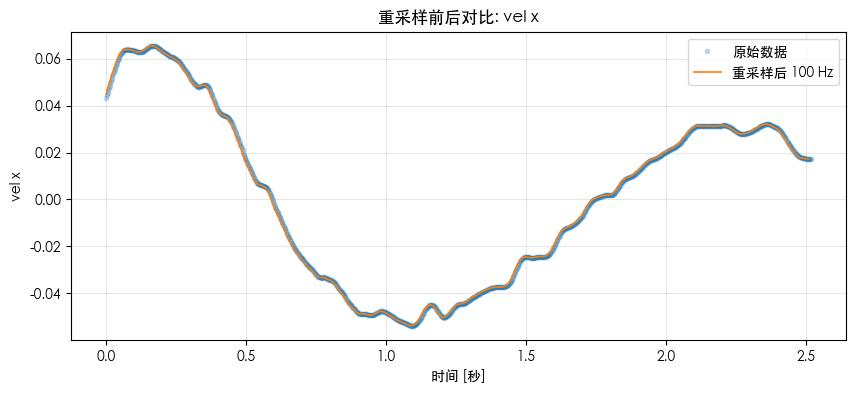

In [6]:
plot_column = "vel x"

raw_time_seconds = raw["t"] - raw["t"].iloc[0]
resampled_time_seconds = (resampled["t"] - resampled["t"].iloc[0]).dt.total_seconds()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(raw_time_seconds, raw[plot_column], ".", alpha=0.25, label="原始数据")
ax.plot(resampled_time_seconds, resampled[plot_column], "-", linewidth=1.2, label="重采样后 100 Hz")
ax.set_title(f"重采样前后对比: {plot_column}")
ax.set_xlabel("时间 [秒]")
ax.set_ylabel(plot_column)
ax.legend()
ax.grid(True, alpha=0.3)

## 5. 转成 31D canonical array

In [7]:
canonical_data = extract_neurobem_full_state(resampled)

print("canonical_data shape:", canonical_data.shape)
print("feature 数量:", len(CANONICAL_FEATURE_NAMES))
display(pd.DataFrame(canonical_data[:5], columns=CANONICAL_FEATURE_NAMES))

canonical_data shape: (252, 31)
feature 数量: 31


,p_W_x,p_W_y,p_W_z,v_W_x,v_W_y,v_W_z,q_WB_w,q_WB_x,q_WB_y,q_WB_z,...,u_3,u_4,v_B_x,v_B_y,v_B_z,dmot_1,dmot_2,dmot_3,dmot_4,vbat
0,-3.984205,1.232750,0.186401,0.019643,0.224967,0.714783,0.996987,-0.038622,0.000645,0.067262,...,1.249182,1.162899,0.044993,0.164640,0.729918,0.542924,-0.875881,-0.739841,-1.037225,163.961823
1,-3.984004,1.235013,0.193576,0.021050,0.231755,0.725734,0.997086,-0.035850,-0.000465,0.067319,...,1.242164,1.151313,0.049149,0.174304,0.740301,0.693432,-0.007911,-0.918452,-1.178853,164.019821
2,-3.983787,1.237318,0.200831,0.022481,0.238759,0.737323,0.997175,-0.033289,-0.001346,0.067345,...,1.226257,1.143002,0.053039,0.183962,0.751333,-0.106749,-0.775104,-2.215479,-0.300974,164.067627
3,-3.983568,1.239731,0.208250,0.023935,0.245742,0.749476,0.997249,-0.030898,-0.001913,0.067408,...,1.205127,1.144962,0.056523,0.193444,0.762929,-1.195539,-1.165504,-1.487934,0.563936,164.103790
4,-3.983349,1.242261,0.215846,0.025342,0.252185,0.761757,0.997310,-0.028700,-0.002434,0.067397,...,1.201300,1.151477,0.059800,0.202219,0.774626,-1.520549,-0.751874,0.589320,0.633364,164.130829


In [8]:
feature_schema = pd.DataFrame({
    "index": np.arange(len(CANONICAL_FEATURE_NAMES)),
    "feature": CANONICAL_FEATURE_NAMES,
})
display(feature_schema)

slice_schema = pd.DataFrame([
    {"group": name, "start": bounds[0], "end": bounds[1], "features": CANONICAL_FEATURE_NAMES[bounds[0]:bounds[1]]}
    for name, bounds in CANONICAL_FEATURE_SLICES.items()
])
display(slice_schema)

,index,feature
0,0,p_W_x
1,1,p_W_y
2,2,p_W_z
3,3,v_W_x
4,4,v_W_y
5,5,v_W_z
6,6,q_WB_w
7,7,q_WB_x
8,8,q_WB_y
9,9,q_WB_z


,group,start,end,features
0,p_W,0,3,"[p_W_x, p_W_y, p_W_z]"
1,v_W,3,6,"[v_W_x, v_W_y, v_W_z]"
2,q,6,10,"[q_WB_w, q_WB_x, q_WB_y, q_WB_z]"
3,omega_B,10,13,"[omega_B_x, omega_B_y, omega_B_z]"
4,a,13,16,"[a_x, a_y, a_z]"
5,alpha,16,19,"[alpha_x, alpha_y, alpha_z]"
6,u,19,23,"[u_1, u_2, u_3, u_4]"
7,v_B,23,26,"[v_B_x, v_B_y, v_B_z]"
8,dmot,26,30,"[dmot_1, dmot_2, dmot_3, dmot_4]"
9,vbat,30,31,[vbat]


## 6. 写成 canonical HDF5 的结构

正式转换时，每个 split 会写一个 HDF5：

```text
resources/data/neurobemfullstate/train/train.h5
resources/data/neurobemfullstate/valid/valid.h5
resources/data/neurobemfullstate/test/test.h5
```

HDF5 里保留两种读取方式：

- `data`: 把当前 split 的所有 trajectory 拼起来的二维数组。
- `trajectory_starts` / `trajectory_lengths`: 每条 trajectory 在 `data` 里的边界。
- `trajectories/<trajectory_name>/data`: 每条 trajectory 单独保存。

In [9]:
tmp_root = Path(tempfile.mkdtemp(prefix="neurobemfullstate-demo-"))
tmp_source_split = tmp_root / "source" / SPLIT
tmp_output_split = tmp_root / "out" / SPLIT
tmp_source_split.mkdir(parents=True)
tmp_output_split.mkdir(parents=True)
shutil.copy(csv_path, tmp_source_split / csv_path.name)

h5_path = write_canonical_split_hdf5(str(tmp_source_split), str(tmp_output_split), f"{SPLIT}.h5")
print("临时 HDF5:", h5_path)

with h5py.File(h5_path, "r") as hf:
    print("keys:", list(hf.keys()))
    print("dataset_name:", hf.attrs["dataset_name"])
    print("data shape:", hf["data"].shape)
    print("trajectory_starts:", hf["trajectory_starts"][:])
    print("trajectory_lengths:", hf["trajectory_lengths"][:])
    print("feature_names:", json.loads(hf.attrs["feature_names"])[:8], "...")
    trajectory_name = json.loads(hf.attrs["trajectory_names"])[0]
    print("第一条 trajectory:", trajectory_name)
    print("trajectory data shape:", hf["trajectories"][trajectory_name]["data"].shape)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 137.27it/s]

临时 HDF5: /var/folders/68/nvmmcnln3kg5x6_8kcq7bxxw0000gn/T/neurobemfullstate-demo-y8f2r091/out/train/train.h5
keys: ['data', 'trajectories', 'trajectory_lengths', 'trajectory_starts']
dataset_name: neurobemfullstate
data shape: (252, 31)
trajectory_starts: [0]
trajectory_lengths: [252]
feature_names: ['p_W_x', 'p_W_y', 'p_W_z', 'v_W_x', 'v_W_y', 'v_W_z', 'q_WB_w', 'q_WB_x'] ...
第一条 trajectory: merged_2021-02-03-13-43-38_seg_1
trajectory data shape: (252, 31)


## 7. split 和动态 window 演示

这里补上两个容易混在一起的“切分”：

- **数据集 split**：原始 CSV 已经放在 `train` / `valid` / `test` 三个目录里，脚本会分别生成三个 HDF5。
- **训练 window**：HDF5 不保存固定的 `history_length` / `unroll_length`，后面的 PyTorch Dataset 训练时再从完整 trajectory 里动态切。


In [10]:
split_rows = []
for split_name in ["train", "valid", "test"]:
    source_split = SOURCE_DATA_DIR / split_name
    output_h5 = CANONICAL_DATA_DIR / split_name / f"{split_name}.h5"
    split_rows.append({
        "split": split_name,
        "CSV 数量": len(list(source_split.glob("*.csv"))),
        "输入目录": str(source_split.relative_to(REPO_ROOT)),
        "输出 HDF5": str(output_h5.relative_to(REPO_ROOT)),
    })

display(pd.DataFrame(split_rows))


,split,CSV 数量,输入目录,输出 HDF5
0,train,236,resources/data/neurobem/train,resources/data/neurobemfullstate/train/train.h5
1,valid,11,resources/data/neurobem/valid,resources/data/neurobemfullstate/valid/valid.h5
2,test,12,resources/data/neurobem/test,resources/data/neurobemfullstate/test/test.h5


### 动态切 history / future window
`neurobemfullstate` 在 HDF5 里存的是完整 trajectory 的 31 列，后面训练时再按需要切：

- 13D state：`p_W + v_W + q_WB + omega_B`
- 10D state：`v_W + q_WB + omega_B`
- control：`u`
- context：`v_B + dmot + vbat`



In [11]:
with h5py.File(h5_path, "r") as hf:
    trajectory_name = json.loads(hf.attrs["trajectory_names"])[0]
    trajectory_data = hf["trajectories"][trajectory_name]["data"][:]
    feature_slices = json.loads(hf.attrs["feature_slices"])
p_W_slice = slice(*feature_slices["p_W"])
v_W_slice = slice(*feature_slices["v_W"])
q_slice = slice(*feature_slices["q"])
omega_B_slice = slice(*feature_slices["omega_B"])
u_slice = slice(*feature_slices["u"])
v_B_slice = slice(*feature_slices["v_B"])
dmot_slice = slice(*feature_slices["dmot"])
vbat_slice = slice(*feature_slices["vbat"])

state_13 = np.hstack((
    trajectory_data[:, p_W_slice],
    trajectory_data[:, v_W_slice],
    trajectory_data[:, q_slice],
    trajectory_data[:, omega_B_slice],
))
state_10 = np.hstack((
    trajectory_data[:, v_W_slice],
    trajectory_data[:, q_slice],
    trajectory_data[:, omega_B_slice],
))
u = trajectory_data[:, u_slice]
context = np.hstack((trajectory_data[:, v_B_slice], trajectory_data[:, dmot_slice], trajectory_data[:, vbat_slice]))

start = 0
H = 20  #history length
F = 10  #future length

x_hist_13 = state_13[start:start + H]
y_future_13 = state_13[start + H:start + H + F]
y_future_10 = state_10[start + H:start + H + F]
u_hist = u[start:start + H]
u_roll = u[start + H:start + H + F]
c_hist = context[start:start + H]

shape_summary = pd.DataFrame({
    "张量": ["x_hist_13", "y_future_13", "y_future_10", "u_hist", "u_roll", "c_hist"],
    "含义": [
        "过去 H 步 13D 状态",
        "未来 F 步 13D 状态",
        "未来 F 步 10D 状态",
        "过去 H 步电机输入",
        "未来 F 步电机输入",
        "过去 H 步 context：v_B + dmot + vbat",
    ],
    "shape": [
        x_hist_13.shape,
        y_future_13.shape,
        y_future_10.shape,
        u_hist.shape,
        u_roll.shape,
        c_hist.shape,
    ],
})
display(shape_summary)#(时间步数量, 每个时间步有多少个数值特征)


,张量,含义,shape
0,x_hist_13,过去 H 步 13D 状态,"(20, 13)"
1,y_future_13,未来 F 步 13D 状态,"(10, 13)"
2,y_future_10,未来 F 步 10D 状态,"(10, 10)"
3,u_hist,过去 H 步电机输入,"(20, 4)"
4,u_roll,未来 F 步电机输入,"(10, 4)"
5,c_hist,过去 H 步 context：v_B + dmot + vbat,"(20, 8)"


### 换 H / F 不需要重写 HDF5

下面还是用同一个 `trajectory_data`，只改 `H` 和 `F`。如果 shape 变了，就说明窗口是在训练前临时切的，不是写死在 HDF5 里的。


In [12]:
H2 = 50
F2 = 25

x_hist_13_v2 = state_13[start:start + H2]
y_future_13_v2 = state_13[start + H2:start + H2 + F2]
u_roll_v2 = u[start + H2:start + H2 + F2]
c_hist_v2 = context[start:start + H2]

pd.DataFrame({
    "张量": ["x_hist_13_v2", "y_future_13_v2", "u_roll_v2", "c_hist_v2"],
    "shape": [
        x_hist_13_v2.shape,
        y_future_13_v2.shape,
        u_roll_v2.shape,
        c_hist_v2.shape,
    ],
})


,张量,shape
0,x_hist_13_v2,"(50, 13)"
1,y_future_13_v2,"(25, 13)"
2,u_roll_v2,"(25, 4)"
3,c_hist_v2,"(50, 8)"


## 8. 补充：canonical HDF5 数据审计

这一节只检查数据，不修改数据。它主要回答七个问题：

1. HDF5 里是否有 `data` / `trajectory_starts` / `trajectory_lengths`。
2. `feature_names` 和 `feature_slices` 是否能正确解析。
3. 四元数 `q` 的 norm 是否接近 1。
4. 四元数是否有符号跳变：`dot(q_t, q_{t-1}) < 0`。
5. 位置和速度是否满足基本运动学一致性。
6. `u` / `v_B` / `dmot` / `vbat` 是否有 NaN。
7. 每条 trajectory 长度是否足够切出 `H + F`。

默认会审计上面临时生成的 HDF5。如果你已经正式生成了 `resources/data/neurobemfullstate/train/train.h5`，下面的代码会优先审计正式 HDF5。


In [13]:
def quaternion_wxyz_to_rotation_matrix(q):
    q = q / np.linalg.norm(q, axis=1, keepdims=True)
    w = q[:, 0]
    x = q[:, 1]
    y = q[:, 2]
    z = q[:, 3]

    R = np.empty((q.shape[0], 3, 3), dtype=q.dtype)
    R[:, 0, 0] = 1 - 2 * (y * y + z * z)
    R[:, 0, 1] = 2 * (x * y - z * w)
    R[:, 0, 2] = 2 * (x * z + y * w)
    R[:, 1, 0] = 2 * (x * y + z * w)
    R[:, 1, 1] = 1 - 2 * (x * x + z * z)
    R[:, 1, 2] = 2 * (y * z - x * w)
    R[:, 2, 0] = 2 * (x * z - y * w)
    R[:, 2, 1] = 2 * (y * z + x * w)
    R[:, 2, 2] = 1 - 2 * (x * x + y * y)
    return R


def summarize_error(name, error):
    return {
        "速度解释": name,
        "mean |位置误差|": float(np.mean(error)),
        "median |位置误差|": float(np.median(error)),
        "p95 |位置误差|": float(np.percentile(error, 95)),
    }


def audit_canonical_hdf5(h5_file_path, H, F):
    h5_file_path = Path(h5_file_path)
    print("审计 HDF5:", h5_file_path)
    print("当前 window 需要时间步:", H + F, f"= H({H}) + F({F})")

    with h5py.File(h5_file_path, "r") as hf:
        required_keys = ["data", "trajectory_starts", "trajectory_lengths"]
        structure_summary = pd.DataFrame({
            "HDF5 项": required_keys,
            "是否存在": [key in hf for key in required_keys],
        })
        print("\n[1/7] HDF5 结构检查：下面三项都应该是 True")
        print(structure_summary.to_string(index=False))
        display(structure_summary)

        data = hf["data"][:]
        trajectory_starts = hf["trajectory_starts"][:]
        trajectory_lengths = hf["trajectory_lengths"][:]
        trajectory_names = json.loads(hf.attrs["trajectory_names"])
        feature_names = json.loads(hf.attrs["feature_names"])
        feature_slices = json.loads(hf.attrs["feature_slices"])
        dt = float(hf.attrs.get("dt_seconds", CANONICAL_DT_SECONDS))

    feature_parse_summary = pd.DataFrame([
        {"检查": "feature_names 数量等于 data 的列数", "结果": len(feature_names) == data.shape[1], "值": f"{len(feature_names)} vs {data.shape[1]}"},
        {"检查": "feature_slices 是 dict", "结果": isinstance(feature_slices, dict), "值": type(feature_slices).__name__},
        {"检查": "所有 slice 都在列范围内", "结果": all(0 <= v[0] < v[1] <= data.shape[1] for v in feature_slices.values()), "值": f"feature_dim={data.shape[1]}"},
    ])
    print("\n[2/7] feature_names / feature_slices 解析检查：结果都应该是 True")
    print(feature_parse_summary.to_string(index=False))
    display(feature_parse_summary)

    slice_summary = []
    for name, bounds in feature_slices.items():
        start_idx, end_idx = bounds
        slice_summary.append({
            "slice": name,
            "范围": f"[{start_idx}, {end_idx})",
            "维度": end_idx - start_idx,
            "列名": ", ".join(feature_names[start_idx:end_idx]),
        })
    slice_summary_df = pd.DataFrame(slice_summary)
    print("\nfeature_slices 具体列范围：确认每个字段对应哪些列")
    print(slice_summary_df.to_string(index=False))
    display(slice_summary_df)

    q_slice = slice(*feature_slices["q"])
    q = data[:, q_slice]
    q_norm = np.linalg.norm(q, axis=1)
    q_dot = np.sum(q[1:] * q[:-1], axis=1)
    q_summary = pd.DataFrame([
        {"检查": "q norm 平均值", "值": float(np.mean(q_norm))},
        {"检查": "max |q_norm - 1|", "值": float(np.max(np.abs(q_norm - 1)))},
        {"检查": "dot(q_t, q_{t-1}) < 0 的次数", "值": int(np.sum(q_dot < 0))},
    ])
    print("\n[3/7] q norm 检查：q norm 应该接近 1")
    print("[4/7] q 符号跳变检查：dot(q_t, q_{t-1}) < 0 的次数越少越好")
    print(q_summary.to_string(index=False))
    display(q_summary)

    nan_summary = []
    for name in ["u", "v_B", "dmot", "vbat"]:
        values = data[:, slice(*feature_slices[name])]
        nan_summary.append({
            "字段": name,
            "NaN 数量": int(np.isnan(values).sum()),
            "总元素数": int(values.size),
        })
    nan_summary_df = pd.DataFrame(nan_summary)
    print("\n[5/7] u / v_B / dmot / vbat NaN 检查：NaN 数量应该是 0")
    print(nan_summary_df.to_string(index=False))
    display(nan_summary_df)

    length_summary = pd.DataFrame({
        "trajectory": trajectory_names,
        "长度 T": trajectory_lengths,
        "需要 H+F": H + F,
        "是否足够": trajectory_lengths >= H + F,
    })
    print("\n[6/7] trajectory 长度检查：长度 T 要大于等于 H+F")
    print(length_summary.to_string(index=False))
    display(length_summary)

    p_slice = slice(*feature_slices["p_W"])
    velocity_key = "v_W" if "v_W" in feature_slices else "v_B"
    velocity_label = velocity_key
    v_slice = slice(*feature_slices[velocity_key])

    error_as_stored = []
    error_R_v = []
    error_RT_v = []

    for start_idx, length in zip(trajectory_starts, trajectory_lengths):
        trajectory = data[start_idx:start_idx + length]
        p = trajectory[:, p_slice]
        v_raw = trajectory[:, v_slice]
        q = trajectory[:, q_slice]

        dp = p[1:] - p[:-1]
        v_step = v_raw[:-1]
        R = quaternion_wxyz_to_rotation_matrix(q[:-1])

        pred_as_stored = v_step * dt
        pred_R_v = np.einsum("nij,nj->ni", R, v_step) * dt
        pred_RT_v = np.einsum("nji,nj->ni", R, v_step) * dt

        error_as_stored.append(np.linalg.norm(dp - pred_as_stored, axis=1))
        error_R_v.append(np.linalg.norm(dp - pred_R_v, axis=1))
        error_RT_v.append(np.linalg.norm(dp - pred_RT_v, axis=1))

    error_as_stored = np.concatenate(error_as_stored)
    error_R_v = np.concatenate(error_R_v)
    error_RT_v = np.concatenate(error_RT_v)

    p_v_summary = pd.DataFrame([
        summarize_error(f"直接使用 canonical {velocity_label}: Δp ≈ {velocity_label} * dt", error_as_stored),
        summarize_error(f"错误地再做 R(q) @ {velocity_label}: Δp ≈ R(q) @ {velocity_label} * dt", error_R_v),
        summarize_error(f"错误地再做 R(q).T @ {velocity_label}: Δp ≈ R(q).T @ {velocity_label} * dt", error_RT_v),
    ]).sort_values("mean |位置误差|")
    print("\n[7/7] p-v kinematic consistency：mean |位置误差| 最小的速度解释最可信")
    print(p_v_summary.to_string(index=False))
    display(p_v_summary)

    best_velocity_interpretation = p_v_summary.iloc[0]["速度解释"]
    print("\n审计结论")
    print("- HDF5 结构完整:", bool(structure_summary["是否存在"].all()))
    print("- feature schema 可解析:", bool(feature_parse_summary["结果"].all()))
    print("- max |q_norm - 1|:", float(np.max(np.abs(q_norm - 1))))
    print("- q 符号跳变次数:", int(np.sum(q_dot < 0)))
    print("- u/v_B/dmot/vbat NaN 总数:", int(nan_summary_df["NaN 数量"].sum()))
    print("- 所有 trajectory 足够切 H+F:", bool(length_summary["是否足够"].all()))
    print("- canonical p-v consistency 最小误差解释:", best_velocity_interpretation)

    return {
        "structure_summary": structure_summary,
        "feature_parse_summary": feature_parse_summary,
        "q_summary": q_summary,
        "nan_summary": nan_summary_df,
        "length_summary": length_summary,
        "p_v_summary": p_v_summary,
    }


In [14]:
generated_h5_paths = [
    CANONICAL_DATA_DIR / split_name / f"{split_name}.h5"
    for split_name in ["train", "valid", "test"]
]
existing_generated_h5_paths = [path for path in generated_h5_paths if path.exists()]

AUDIT_H5_PATHS = existing_generated_h5_paths if existing_generated_h5_paths else [Path(h5_path)]

audit_results = {}
for audit_h5_path in AUDIT_H5_PATHS:
    audit_results[str(audit_h5_path)] = audit_canonical_hdf5(audit_h5_path, H=H, F=F)


审计 HDF5: /var/folders/68/nvmmcnln3kg5x6_8kcq7bxxw0000gn/T/neurobemfullstate-demo-y8f2r091/out/train/train.h5
当前 window 需要时间步: 30 = H(20) + F(10)

[1/7] HDF5 结构检查：下面三项都应该是 True
            HDF5 项  是否存在
              data  True
 trajectory_starts  True
trajectory_lengths  True


,HDF5 项,是否存在
0,data,True
1,trajectory_starts,True
2,trajectory_lengths,True



[2/7] feature_names / feature_slices 解析检查：结果都应该是 True
                         检查   结果              值
feature_names 数量等于 data 的列数 True       31 vs 31
      feature_slices 是 dict True           dict
            所有 slice 都在列范围内 True feature_dim=31


,检查,结果,值
0,feature_names 数量等于 data 的列数,True,31 vs 31
1,feature_slices 是 dict,True,dict
2,所有 slice 都在列范围内,True,feature_dim=31



feature_slices 具体列范围：确认每个字段对应哪些列
  slice       范围  维度                              列名
    p_W   [0, 3)   3             p_W_x, p_W_y, p_W_z
    v_W   [3, 6)   3             v_W_x, v_W_y, v_W_z
      q  [6, 10)   4  q_WB_w, q_WB_x, q_WB_y, q_WB_z
omega_B [10, 13)   3 omega_B_x, omega_B_y, omega_B_z
      a [13, 16)   3                   a_x, a_y, a_z
  alpha [16, 19)   3       alpha_x, alpha_y, alpha_z
      u [19, 23)   4              u_1, u_2, u_3, u_4
    v_B [23, 26)   3             v_B_x, v_B_y, v_B_z
   dmot [26, 30)   4  dmot_1, dmot_2, dmot_3, dmot_4
   vbat [30, 31)   1                            vbat


...


[6/7] trajectory 长度检查：长度 T 要大于等于 H+F
                      trajectory  长度 T  需要 H+F  是否足够
merged_2021-02-03-13-43-38_seg_1   252      30  True


,trajectory,长度 T,需要 H+F,是否足够
0,merged_2021-02-03-13-43-38_seg_1,252,30,True



[7/7] p-v kinematic consistency：mean |位置误差| 最小的速度解释最可信
                                      速度解释  mean |位置误差|  median |位置误差|  p95 |位置误差|
         直接使用 canonical v_W: Δp ≈ v_W * dt     0.000071       0.000063    0.000149
    错误地再做 R(q) @ v_W: Δp ≈ R(q) @ v_W * dt     0.000427       0.000268    0.001227
错误地再做 R(q).T @ v_W: Δp ≈ R(q).T @ v_W * dt     0.000461       0.000270    0.001302


,速度解释,mean |位置误差|,median |位置误差|,p95 |位置误差|
0,直接使用 canonical v_W: Δp ≈ v_W * dt,0.000071,0.000063,0.000149
1,错误地再做 R(q) @ v_W: Δp ≈ R(q) @ v_W * dt,0.000427,0.000268,0.001227
2,错误地再做 R(q).T @ v_W: Δp ≈ R(q).T @ v_W * dt,0.000461,0.000270,0.001302



审计结论
- HDF5 结构完整: True
- feature schema 可解析: True
- max |q_norm - 1|: 1.33514404296875e-05
- q 符号跳变次数: 0
- u/v_B/dmot/vbat NaN 总数: 0
- 所有 trajectory 足够切 H+F: True
- canonical p-v consistency 最小误差解释: 直接使用 canonical v_W: Δp ≈ v_W * dt


## 9. velocity-frame 旋转方向检查

NeuroBEM README 说明 `vel x/y/z` 是 body frame velocity。现在 canonical HDF5 里已经保留了原始 `v_B`，这里用它重新做 finite-difference 速度检查，确认 quaternion 的旋转方向：

```text
p_dot_fd = (p_W[t+1] - p_W[t]) / dt

e_raw = ||p_dot_fd - v_raw||
e_R = ||p_dot_fd - R(q) @ v_raw||
e_R_T = ||p_dot_fd - R(q).T @ v_raw||
```

结论规则：

- 如果 `e_R` 最小，canonical 里应该用 `v_W = R(q) @ v_B`。
- 如果 `e_R_T` 最小，canonical 里应该用 `v_W = R(q).T @ v_B`。
- 如果 `e_raw` 最小，说明 raw velocity 已经更像 world frame velocity。


In [15]:
def check_velocity_rotation_direction(h5_file_path):
    h5_file_path = Path(h5_file_path)
    print("检查 quaternion 旋转方向:", h5_file_path)

    with h5py.File(h5_file_path, "r") as hf:
        data = hf["data"][:]
        trajectory_starts = hf["trajectory_starts"][:]
        trajectory_lengths = hf["trajectory_lengths"][:]
        trajectory_names = json.loads(hf.attrs["trajectory_names"])
        feature_slices = json.loads(hf.attrs["feature_slices"])
        dt = float(hf.attrs.get("dt_seconds", CANONICAL_DT_SECONDS))

    p_slice = slice(*feature_slices["p_W"])
    q_slice = slice(*feature_slices["q"])
    velocity_key = "v_B" if "v_B" in feature_slices else "v_W"
    v_slice = slice(*feature_slices[velocity_key])

    print("用于旋转方向检查的 velocity 字段名:", velocity_key)
    print("这里应该优先使用保留下来的原始机体系速度 v_B。")
    print("dt:", dt)

    all_e_raw = []
    all_e_R = []
    all_e_R_T = []
    per_trajectory_rows = []

    for trajectory_name, start_idx, length in zip(trajectory_names, trajectory_starts, trajectory_lengths):
        trajectory = data[start_idx:start_idx + length]
        p_W = trajectory[:, p_slice]
        q = trajectory[:, q_slice]
        v_raw = trajectory[:, v_slice]

        p_dot_fd = (p_W[1:] - p_W[:-1]) / dt
        v_step = v_raw[:-1]
        R = quaternion_wxyz_to_rotation_matrix(q[:-1])

        v_raw_as_W = v_step
        v_R_as_W = np.einsum("nij,nj->ni", R, v_step)
        v_R_T_as_W = np.einsum("nji,nj->ni", R, v_step)

        e_raw = np.linalg.norm(p_dot_fd - v_raw_as_W, axis=1)
        e_R = np.linalg.norm(p_dot_fd - v_R_as_W, axis=1)
        e_R_T = np.linalg.norm(p_dot_fd - v_R_T_as_W, axis=1)

        all_e_raw.append(e_raw)
        all_e_R.append(e_R)
        all_e_R_T.append(e_R_T)

        mean_errors = {
            "e_raw": float(np.mean(e_raw)),
            "e_R": float(np.mean(e_R)),
            "e_R_T": float(np.mean(e_R_T)),
        }
        per_trajectory_rows.append({
            "trajectory": trajectory_name,
            "长度 T": int(length),
            "mean e_raw": mean_errors["e_raw"],
            "mean e_R": mean_errors["e_R"],
            "mean e_R_T": mean_errors["e_R_T"],
            "best": min(mean_errors, key=mean_errors.get),
        })

    all_e_raw = np.concatenate(all_e_raw)
    all_e_R = np.concatenate(all_e_R)
    all_e_R_T = np.concatenate(all_e_R_T)

    overall_summary = pd.DataFrame([
        {
            "误差": "e_raw",
            "速度解释": "直接把 raw velocity 当 world velocity",
            "mean |速度误差|": float(np.mean(all_e_raw)),
            "median |速度误差|": float(np.median(all_e_raw)),
            "p95 |速度误差|": float(np.percentile(all_e_raw, 95)),
        },
        {
            "误差": "e_R",
            "速度解释": "把 raw velocity 当 body velocity，用 R(q) 转到 world",
            "mean |速度误差|": float(np.mean(all_e_R)),
            "median |速度误差|": float(np.median(all_e_R)),
            "p95 |速度误差|": float(np.percentile(all_e_R, 95)),
        },
        {
            "误差": "e_R_T",
            "速度解释": "把 raw velocity 当 body velocity，用 R(q).T 转到 world",
            "mean |速度误差|": float(np.mean(all_e_R_T)),
            "median |速度误差|": float(np.median(all_e_R_T)),
            "p95 |速度误差|": float(np.percentile(all_e_R_T, 95)),
        },
    ]).sort_values("mean |速度误差|")

    per_trajectory_summary = pd.DataFrame(per_trajectory_rows)

    print("\n每条 trajectory 的 mean error：")
    print(per_trajectory_summary.to_string(index=False))
    display(per_trajectory_summary)

    print("\n全局 finite-difference velocity error：mean 最小者就是最可信的旋转方向")
    print(overall_summary.to_string(index=False))
    display(overall_summary)

    best_error = overall_summary.iloc[0]["误差"]
    if best_error == "e_R":
        recommendation = "v_W = R(q) @ v_B"
    elif best_error == "e_R_T":
        recommendation = "v_W = R(q).T @ v_B"
    else:
        recommendation = "raw velocity 可以直接当 v_W 使用"

    print("\n旋转方向检查结论")
    print("- 最小误差项:", best_error)
    print("- 推荐 canonical 速度处理:", recommendation)

    return {
        "per_trajectory_summary": per_trajectory_summary,
        "overall_summary": overall_summary,
        "recommendation": recommendation,
    }


rotation_direction_results = {}
for audit_h5_path in AUDIT_H5_PATHS:
    rotation_direction_results[str(audit_h5_path)] = check_velocity_rotation_direction(audit_h5_path)


检查 quaternion 旋转方向: /var/folders/68/nvmmcnln3kg5x6_8kcq7bxxw0000gn/T/neurobemfullstate-demo-y8f2r091/out/train/train.h5
用于旋转方向检查的 velocity 字段名: v_B
这里应该优先使用保留下来的原始机体系速度 v_B。
dt: 0.01

每条 trajectory 的 mean error：
                      trajectory  长度 T  mean e_raw  mean e_R  mean e_R_T best
merged_2021-02-03-13-43-38_seg_1   252    0.046084  0.007105     0.08897  e_R


,trajectory,长度 T,mean e_raw,mean e_R,mean e_R_T,best
0,merged_2021-02-03-13-43-38_seg_1,252,0.046084,0.007105,0.08897,e_R



全局 finite-difference velocity error：mean 最小者就是最可信的旋转方向
   误差                                             速度解释  mean |速度误差|  median |速度误差|  p95 |速度误差|
  e_R   把 raw velocity 当 body velocity，用 R(q) 转到 world     0.007105       0.006326    0.014866
e_raw                直接把 raw velocity 当 world velocity     0.046084       0.026959    0.130245
e_R_T 把 raw velocity 当 body velocity，用 R(q).T 转到 world     0.088970       0.053774    0.256389


,误差,速度解释,mean |速度误差|,median |速度误差|,p95 |速度误差|
1,e_R,把 raw velocity 当 body velocity，用 R(q) 转到 world,0.007105,0.006326,0.014866
0,e_raw,直接把 raw velocity 当 world velocity,0.046084,0.026959,0.130245
2,e_R_T,把 raw velocity 当 body velocity，用 R(q).T 转到 world,0.088970,0.053774,0.256389



旋转方向检查结论
- 最小误差项: e_R
- 推荐 canonical 速度处理: v_W = R(q) @ v_B


## 10. 正式生成 neurobemfullstate

在终端里运行下面这两行：

```bash
cd /Users/lixiang/Developer/long-horizon-dynamics/scripts
/opt/anaconda3/envs/long/bin/python hdf5.py --dataset neurobemfullstate
```

第一行是进入脚本目录。第二行是用 `long` 环境运行数据处理脚本，从 `resources/data/neurobem` 读取 CSV，生成 `resources/data/neurobemfullstate`。

## 代码阅读路线

- `scripts/hdf5.py`: 生成 `neurobemfullstate` canonical HDF5。
- `CANONICAL_FEATURE_NAMES`: 31D feature 顺序。
- `CANONICAL_FEATURE_SLICES`: 后续模型按组切列的位置。